# TCN for Sales Drop Detection

This notebook is part of a multi-model comparison study (TCN, LightGBM, Isolation Forest) for detecting anomalous hourly sales drops. All models share the same data, preprocessing pipeline, and anomaly scoring logic to ensure a fair comparison.

The notebook is designed as a **universal training template** — model architecture and training procedure are fixed, while the anomaly detection method is interchangeable. This lets us reuse the same trained model across different thresholding strategies without retraining.

A Temporal Convolutional Network is trained to forecast hourly sales. Once trained, several anomaly detection variants are tested on top of the same predictions: `z-score < -4.5`, `sigma = 5`, and `sigma = 3.5`. The training pipeline stays identical regardless of which threshold variant is active.

**Active threshold in this notebook: z-score < -4.5**

## The setup

- **Data**: hourly sales, January–August 2025
- **Scope**: top-500 products by August volume + 13 products with known labeled anomalies
- **Model**: global TCN with product/category embeddings, 168-hour lookback window
- **Training**: AdamW optimizer, early stopping with patience=3
- **Loss function**: Huber loss (`delta=1.0` in TCN, matching LightGBM's `objective='huber'`) — intentionally aligned across models to eliminate loss function differences from the comparison
- **Anomaly detection**: multiple threshold variants tested on the same predictions; currently active is `z-score < -4.5`

## Results on labeled anomalies

The model detected **5 out of 65** labeled anomalies (60 missed, 1128 false positives).

This low recall is expected given the experimental constraints. The top-500 products form an unusually stable group — high volume, low variability. Synthetic zeroing-out events on these products don't deviate enough from the dense normality to cross the detection threshold. In a more diverse product catalog, the same anomalies would stand out more sharply.

## Note on threshold variants

Several anomaly scoring approaches were tested on top of the same trained model:

1. **Global z-score (active)** — `z-score < -4.5`, matching the LightGBM comparison baseline.

2. **Sigma-threshold on positive errors (commented out)** — `threshold = mean + σ × std` using only residuals where predicted exceeds actual. Two sigma values were tested: `σ = 5` and `σ = 3.5`. These variants are kept as commented reference blocks.

The training pipeline and model checkpoint are shared across all variants — only the anomaly decision boundary changes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import gc
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

In [2]:
DATA_PATH     = '/kaggle/input/datasets/moomivee/data-v1/data_v1.csv'
AUG_AN_PATH   = '/kaggle/input/datasets/moomivee/df-aug/df_aug_final.csv'
AUG_ZERO_PATH = '/kaggle/input/datasets/moomivee/df-aug-zero-rows/df_aug_final_check_rows.csv'
MODEL_PATH    = '/kaggle/working/best_tcn_hourly.pt'
ANOMALIES_OUTPUT_PATH = '/kaggle/working/detected_anomalies_august.csv'

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

print("Initial size:", df.shape)
print(df.head(3))

# Keep data up to August 31
df = df[df['date'] <= '2025-08-31'].copy()

# Remove cold products
first_pos = df[df['sales'] > 0].groupby('product')['date'].min()
aug_start = pd.Timestamp('2025-08-01')
cold = first_pos[first_pos >= aug_start].index.tolist()
df = df[~df['product'].isin(cold)].copy()
print(f"After removing cold products: {df.shape}")

# top 500 in august
aug_df = df[df['date'] >= aug_start].copy()
prod_sales = aug_df.groupby('product')['sales'].sum().reset_index()
prod_sales.columns = ['product', 'total_sales']

top_100 = prod_sales.nlargest(500, 'total_sales')['product'].tolist()

# Products with known anomalies — from AUG_ZERO_PATH
df_aug_zero = pd.read_csv(AUG_ZERO_PATH)
anomaly_products = df_aug_zero['product'].unique().tolist()
print(f"Products with known anomalies: {len(anomaly_products)}")

selected_products = list(set(top_100 + anomaly_products))
print(f"Top-500 (August only): {len(top_100)} | Anomaly products: {len(anomaly_products)} | Total: {len(selected_products)}")

df = df[df['product'].isin(selected_products)].copy()
print(f"After filtering: {df.shape}")

# Free memory
del first_pos, cold, prod_sales, top_100, df_aug_zero, anomaly_products, selected_products, aug_df
gc.collect()

Device: cuda
Initial size: (64081080, 6)
        date          product   category  stocks  sales  price
0 2025-01-15  178462000592214  161040302     5.0    0.0  799.8
1 2025-01-15  178462000291408  162110101     1.0    0.0  199.9
2 2025-01-15  178462000544616  161011010     2.0    0.0  119.9
After removing cold products: (41779767, 6)
Products with known anomalies: 13
Top-500 (August only): 500 | Anomaly products: 13 | Total: 500
After filtering: (2736500, 6)


30

In [4]:
df = df.sort_values(['product', 'date']).reset_index(drop=True)
df['hour'] = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df['sales_log'] = np.log1p(df['sales'])
df['stocks_lag_1h'] = df.groupby('product')['stocks'].shift(1)

product_encoder = LabelEncoder()
category_encoder = LabelEncoder()
df['product_id'] = product_encoder.fit_transform(df['product'])
df['category_id'] = category_encoder.fit_transform(df['category'])

num_products   = df['product_id'].nunique()
num_categories = df['category_id'].nunique()
print(f"Products: {num_products}, Categories: {num_categories}")


class HourlyTCNDataset(Dataset):
    def __init__(self, df, window=168, target_horizon=1):
        self.window = window
        self.target_horizon = target_horizon
        self.samples = []
        self.product_data = {}

        for prod_id in tqdm(df['product_id'].unique(), desc="Preloading products"):
            prod_df = df[df['product_id'] == prod_id].reset_index(drop=True)
            if len(prod_df) < window + target_horizon:
                continue
            self.product_data[prod_id] = {
                'sales':      torch.tensor(prod_df['sales_log'].values, dtype=torch.float32),
                'price':      torch.tensor(prod_df['price'].values,     dtype=torch.float32),
                'hour':       torch.tensor(prod_df['hour'].values,      dtype=torch.float32),
                'dow':        torch.tensor(prod_df['dayofweek'].values, dtype=torch.float32),
                'is_weekend': torch.tensor(prod_df['is_weekend'].values,dtype=torch.float32),
                'category_id':torch.tensor(prod_df['category_id'].iloc[0], dtype=torch.long),
            }
            max_start = len(prod_df) - window - target_horizon + 1
            for i in range(max_start):
                self.samples.append((prod_id, i))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        prod_id, start = self.samples[idx]
        d   = self.product_data[prod_id]
        end = start + self.window
        return {
            'sales':       d['sales'][start:end],
            'price':       d['price'][start:end],
            'hour':        d['hour'][start:end],
            'dow':         d['dow'][start:end],
            'is_weekend':  d['is_weekend'][start:end],
            'product_id':  torch.tensor(prod_id, dtype=torch.long),
            'category_id': d['category_id'],
            'target':      d['sales'][end + self.target_horizon - 1]
        }

train_df = df[df['date'] <= '2025-07-24'].copy()
val_df = df[(df['date'] >= '2025-07-17') & (df['date'] <= '2025-07-31')].copy()

train_dataset = HourlyTCNDataset(train_df, window=168, target_horizon=1)
val_dataset   = HourlyTCNDataset(val_df,   window=168, target_horizon=1)
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

Products: 500, Categories: 154


Preloading products: 100%|██████████| 500/500 [00:00<00:00, 1084.84it/s]

Train samples: 2208500
Val samples:   84000


In [5]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv1   = nn.Conv1d(in_ch,  out_ch, kernel_size, padding=self.padding, dilation=dilation)
        self.conv2   = nn.Conv1d(out_ch, out_ch, kernel_size, padding=self.padding, dilation=dilation)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.res     = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = self.relu(self.conv1(x))
        out = self.dropout(out)
        out = self.relu(self.conv2(out))
        out = self.dropout(out)
        out = out[:, :, :x.size(2)]
        return out + self.res(x)


class GlobalTCN(nn.Module):
    def __init__(self, num_products, num_categories, emb_dim=64, hidden=128, levels=6):
        super().__init__()
        self.product_emb  = nn.Embedding(num_products,   emb_dim)
        self.category_emb = nn.Embedding(num_categories, emb_dim // 2)
        input_dim = 5 + emb_dim + emb_dim // 2
        self.input_proj = nn.Linear(input_dim, hidden)
        dilations = [2 ** i for i in range(levels)]
        self.blocks = nn.ModuleList([TCNBlock(hidden, hidden, 3, d, 0.2) for d in dilations])
        self.head = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, sales, price, hour, dow, is_weekend, product_id, category_id):
        p_emb = self.product_emb(product_id)
        c_emb = self.category_emb(category_id)
        x = torch.stack([sales, price, hour, dow, is_weekend], dim=-1)
        x = torch.cat([x,
                       p_emb.unsqueeze(1).expand(-1, x.size(1), -1),
                       c_emb.unsqueeze(1).expand(-1, x.size(1), -1)], dim=-1)
        x = self.input_proj(x).permute(0, 2, 1)
        for block in self.blocks:
            x = block(x)
        x = x[:, :, -1]
        return self.head(x).squeeze(-1)


model = GlobalTCN(num_products, num_categories).to(device)

In [6]:
from tqdm.auto import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=1.0)

epochs           = 25
best_loss        = float('inf')
patience         = 3
patience_counter = 0
train_losses, val_losses = [], []


def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    desc   = "Training" if train else "Validation"
    loader = tqdm(loader, desc=desc, leave=False)

    with ctx:
        for batch in loader:
            sales       = batch['sales'].to(device,       non_blocking=True)
            price       = batch['price'].to(device,       non_blocking=True)
            hour        = batch['hour'].to(device,        non_blocking=True)
            dow         = batch['dow'].to(device,         non_blocking=True)
            is_weekend  = batch['is_weekend'].to(device,  non_blocking=True)
            product_id  = batch['product_id'].to(device,  non_blocking=True)
            category_id = batch['category_id'].to(device, non_blocking=True)
            target      = batch['target'].to(device,      non_blocking=True)

            if train:
                optimizer.zero_grad()

            pred = model(sales, price, hour, dow, is_weekend, product_id, category_id)
            loss = criterion(pred, target)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            loader.set_postfix(loss=f"{total_loss / (loader.n or 1):.4f}")

    return total_loss / len(loader)

Epochs:   0%|          | 0/25 [00:00<?, ?it/s]

Training:   0%|          | 0/8627 [00:00<?, ?it/s]

Validation:   0%|          | 0/657 [00:00<?, ?it/s]

Epoch 1/25 | Train Loss: 0.0644 | Val Loss: 0.0784
  -> Saved best model


Training:   0%|          | 0/8627 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/657 [00:00<?, ?it/s]

Epoch 12/25 | Train Loss: 0.0583 | Val Loss: 0.0760
  -> No improvement (2/3)


Training:   0%|          | 0/8627 [00:00<?, ?it/s]

Validation:   0%|          | 0/657 [00:00<?, ?it/s]

Epoch 13/25 | Train Loss: 0.0583 | Val Loss: 0.0761
  -> No improvement (3/3)

Early stopping at epoch 13


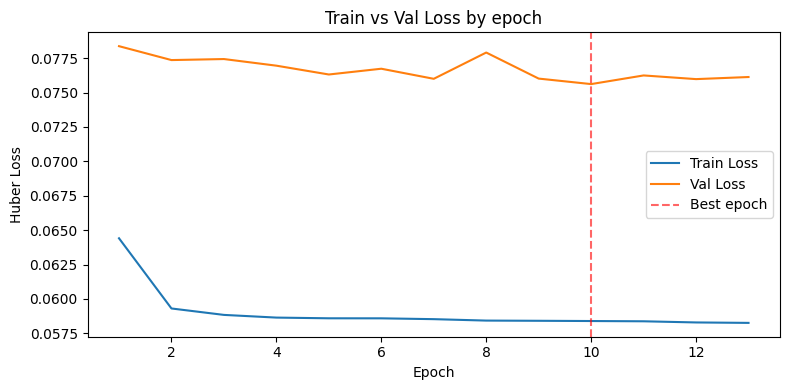


Training complete. Best Val Loss: 0.0756 (epoch 10)


In [7]:
epoch_bar = tqdm(range(epochs), desc="Epochs")

for epoch in epoch_bar:
    tr_loss  = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader,   train=False)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    epoch_bar.set_postfix(train=f"{tr_loss:.4f}", val=f"{val_loss:.4f}")
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print("  -> Saved best model")
    else:
        patience_counter += 1
        print(f"  -> No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Train vs val loss plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1),   val_losses,   label='Val Loss')
plt.axvline(x=val_losses.index(min(val_losses))+1,
            color='red', linestyle='--', alpha=0.6, label='Best epoch')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.title('Train vs Val Loss by epoch')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTraining complete. Best Val Loss: {best_loss:.4f} "
      f"(epoch {val_losses.index(min(val_losses))+1})")

In [8]:
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

val_preds_log, val_targets_log = [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Predicting on val"):
        pred = model(
            batch['sales'].to(device),
            batch['price'].to(device),
            batch['hour'].to(device),
            batch['dow'].to(device),
            batch['is_weekend'].to(device),
            batch['product_id'].to(device),
            batch['category_id'].to(device)
        )
        val_preds_log.append(pred.cpu())
        val_targets_log.append(batch['target'].cpu())

val_preds_real   = np.expm1(torch.cat(val_preds_log).numpy())
val_targets_real = np.expm1(torch.cat(val_targets_log).numpy())

# Model metrics
model_mae  = mean_absolute_error(val_targets_real, val_preds_real)
model_rmse = np.sqrt(mean_squared_error(val_targets_real, val_preds_real))

# Naive baseline: predict[t] = actual[t-1]
naive_mae  = mean_absolute_error(val_targets_real[1:], val_targets_real[:-1])
naive_rmse = np.sqrt(mean_squared_error(val_targets_real[1:], val_targets_real[:-1]))

print(f"{'Metric':<20} {'Baseline':>10} {'TCN':>10}")
print("=" * 42)
print(f"{'MAE':<20} {naive_mae:>10.3f} {model_mae:>10.3f}")
print(f"{'RMSE':<20} {naive_rmse:>10.3f} {model_rmse:>10.3f}")
print("=" * 42)
print(f"MAE improvement:  {(1 - model_mae/naive_mae)*100:.1f}%")
print(f"RMSE improvement: {(1 - model_rmse/naive_rmse)*100:.1f}%")

Predicting on val:   0%|          | 0/657 [00:00<?, ?it/s]

Metric                 Baseline        TCN
MAE                       0.662      0.508
RMSE                      1.997      1.540
MAE improvement:  23.3%
RMSE improvement: 22.9%


In [9]:
print("ANOMALY DETECTION (AUGUST)")

# Include last 3 days of July so the first August window has full context
jul_context = df[(df['date'] >= '2025-07-29') & (df['date'] <= '2025-07-31')].copy()
aug_df = df[df['date'] >= '2025-08-01'].copy()
test_df = pd.concat([jul_context, aug_df]).sort_values(['product', 'date']).reset_index(drop=True)

print(f"Records (with context): {len(test_df)}")

test_dataset = HourlyTCNDataset(test_df, window=168, target_horizon=1)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

all_preds, all_targets = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting on August"):
        pred = model(
            batch['sales'].to(device),
            batch['price'].to(device),
            batch['hour'].to(device),
            batch['dow'].to(device),
            batch['is_weekend'].to(device),
            batch['product_id'].to(device),
            batch['category_id'].to(device)
        )
        all_preds.append(pred.cpu())
        all_targets.append(batch['target'].cpu())

preds = torch.cat(all_preds).numpy()
targets = torch.cat(all_targets).numpy()

preds_real = np.expm1(preds)
targets_real = np.expm1(targets)

print("Predictions completed and saved in memory.")
gc.collect()

ANOMALY DETECTION (AUGUST)
Records (with context): 384500


Preloading products:   0%|          | 0/500 [00:00<?, ?it/s]

Predicting on August:   0%|          | 0/587 [00:00<?, ?it/s]

Predictions completed and saved in memory.


115

### Alternative threshold variant (commented out)

Sigma-based threshold computed on positive residuals only. Kept for reference — two sigma values were tested elsewhere (σ = 3.5, σ = 5).

In [10]:
# sigma = 5
# drop_mask = targets_real < preds_real errors = preds_real - targets_real
# error_mean = np.mean(errors[drop_mask]) error_std = np.std(errors[drop_mask]) anomaly_threshold = error_mean + sigma * error_std
# anomaly_mask = drop_mask & (errors > anomaly_threshold)

# Residual: predicted - actual
errors = preds_real - targets_real

# Global z-score
error_mean = np.mean(errors)
error_std  = np.std(errors)
residual_zscore = (errors - error_mean) / (error_std + 1e-6)

# Threshold
anomaly_mask = residual_zscore < -4.5

print(f"Anomalies found (before filter): {anomaly_mask.sum()}")

# Recover original row indices
target_row_indices = []
for prod_id in test_dataset.product_data.keys():
    prod_idx = test_df[test_df['product_id'] == prod_id].index.tolist()
    for i in range(len(prod_idx) - 168):          # window = 168
        target_row_indices.append(prod_idx[i + 168])

target_row_indices = np.array(target_row_indices)
anomaly_positions = np.where(anomaly_mask)[0]
anomaly_row_indices = target_row_indices[anomaly_positions]

original_anomalies = test_df.loc[anomaly_row_indices].copy()
original_anomalies['predicted_sales']  = preds_real[anomaly_positions]
original_anomalies['real_sales']       = targets_real[anomaly_positions]
original_anomalies['drop_amount']      = errors[anomaly_positions]
original_anomalies['residual_zscore']  = residual_zscore[anomaly_positions]

# Mandatory filter
original_anomalies['mandatory_filter'] = (
    (original_anomalies['stocks_lag_1h'] > 0) &
    (original_anomalies['stocks'] > 0) &
    (original_anomalies['hour'] >= 7) &
    (original_anomalies['hour'] <= 22)
)

final_anomalies = original_anomalies[original_anomalies['mandatory_filter']].copy()
final_anomalies = final_anomalies[final_anomalies['date'] >= '2025-08-01']

print(f"Anomalies after filter (August): {len(final_anomalies)}")

Anomalies found (before filter): 1388
Anomalies after filter (August): 1133


In [12]:
print("ANOMALY DETECTION QUALITY CHECK ON LABELED DATA")

df_aug_an      = pd.read_csv(AUG_AN_PATH)
df_aug_an_zero = pd.read_csv(AUG_ZERO_PATH)

df_aug_an['date']      = pd.to_datetime(df_aug_an['date'])
df_aug_an_zero['date'] = pd.to_datetime(df_aug_an_zero['date'])

# Real anomalies from labels — unique (product, date) keys
real_anomaly_keys = set(
    zip(df_aug_an_zero['product'].astype(str),
        df_aug_an_zero['date'].astype(str))
)

# Model-found anomalies — same keys
found_anomaly_keys = set(
    zip(final_anomalies['product'].astype(str),
        pd.to_datetime(final_anomalies['date']).astype(str))
)

true_positives  = real_anomaly_keys & found_anomaly_keys
false_positives = found_anomaly_keys - real_anomaly_keys
false_negatives = real_anomaly_keys - found_anomaly_keys

precision = len(true_positives) / len(found_anomaly_keys) if found_anomaly_keys else 0
recall    = len(true_positives) / len(real_anomaly_keys)  if real_anomaly_keys  else 0
f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

print(f"\nTotal anomalies in labels (df_aug_an_zero): {len(real_anomaly_keys)}")
print(f"Total found by model:                       {len(found_anomaly_keys)}")
print(f"Correctly found (True Positives):           {len(true_positives)}")
print(f"False Positives:                            {len(false_positives)}")
print(f"Missed anomalies (False Negatives):         {len(false_negatives)}")
print()

ANOMALY DETECTION QUALITY CHECK ON LABELED DATA

Total anomalies in labels (df_aug_an_zero): 65
Total found by model:                       1133
Correctly found (True Positives):           5
False Positives:                            1128
Missed anomalies (False Negatives):         60



In [14]:
# Load already known anomalies
df_known = pd.read_csv(AUG_ZERO_PATH)
df_known['date'] = pd.to_datetime(df_known['date'])

# Build keys for known anomalies
known_keys = set(
    zip(df_known['product'].astype(str),
        df_known['date'].astype(str))
)

# Keep only anomalies not present in AUG_ZERO_PATH
final_anomalies['_key'] = list(
    zip(final_anomalies['product'].astype(str),
        pd.to_datetime(final_anomalies['date']).astype(str))
)

new_anomalies = final_anomalies[~final_anomalies['_key'].isin(known_keys)].drop(columns='_key')

print(f"Total detected:        {len(final_anomalies)}")
print(f"Already in known list: {len(final_anomalies) - len(new_anomalies)}")
print(f"New anomalies only:    {len(new_anomalies)}")

NEW_OUTPUT_PATH = '/kaggle/working/TCN_zscore_4_5.csv'

# Save new anomalies only
new_anomalies.to_csv(NEW_OUTPUT_PATH, index=False)
print(f"Saved to {NEW_OUTPUT_PATH}")

Total detected:        1133
Already in known list: 5
New anomalies only:    1128
Saved to /kaggle/working/TCN_zscore_4_5.csv
